# <span style="color:#336699">NDDI &ndash; Normalized Difference Drought Index</span>
<hr style="border:2px solid #0077b9;">
<div style="text-align: left;">
    <a href="https://github.com/swisstopo/topo-satromo-v2/blob/main/codegallery/jupyter/Python/drought/drought_NDDI.ipynb"><img src="https://img.shields.io/badge/View-GitHub-181717?logo=github" alt="View on GitHub"/></a>
    <a href="https://colab.research.google.com/github/swisstopo/topo-satromo-v2/blob/main/codegallery/jupyter/Python/drought/drought_NDDI.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
</div>
<br>

<b>Abstract.</b> This notebook recreates the
<a href="https://github.com/Open-EO/openeo-community-examples/blob/main/python/NDDI/NDDI_Drought.ipynb" target="_blank">openEO community example <em>NDDI_Drought</em></a>,
but instead of an openEO back-end it uses the <em>SwissEO S2-SR</em> Analysis-Ready Data
published as Cloud Optimized GeoTIFFs in the data.geo.admin.ch STAC catalog
(collection <code>ch.swisstopo.swisseo_s2-sr_v200</code>).

The <b>Normalized Difference Drought Index (NDDI)</b> combines a vegetation-greenness
signal (NDVI) with a vegetation-water signal (NDWI). Where a canopy stays green but
loses water, NDWI drops faster than NDVI and NDDI rises &ndash; an early sign of
drought stress.

$$ NDVI = \frac{NIR - Red}{NIR + Red} \qquad
   NDWI = \frac{NIR - SWIR}{NIR + SWIR} \qquad
   NDDI = \frac{NDVI - NDWI}{NDVI + NDWI} $$

| quantity | Sentinel-2 band | SwissEO S2-SR asset | native resolution |
|----------|-----------------|---------------------|-------------------|
| Red      | B04 | <code>&hellip;_b04_10m.tif</code> | 10 m |
| NIR      | B08 | <code>&hellip;_b08_10m.tif</code> | 10 m |
| SWIR     | B11 | <code>&hellip;_b11_20m.tif</code> | 20 m |
| cloud mask | &ndash; | <code>&hellip;_cloudmask_10m.tif</code> (0 = clear) | 10 m |
| terrain mask | &ndash; | <code>&hellip;_terrainmask_10m.tif</code> (0&ndash;180 = incidence angle in deg, 200 = cast shadow, 255 = nodata) | 10 m |

<b>Area of interest:</b> Bern.
<b>Dates compared:</b> 12 August 2021 and 4 July 2026.

<div style="text-align: justify; margin-left: 15%; margin-right: 15%; font-size: 85%; border-style: solid; border-color: #0077b9; border-width: 1px; padding: 5px;">
The openEO example aggregates a whole May&ndash;July season to a temporal mean. Here we
follow the user request and use a single mosaic per date, so a cloud or a snow patch on
one acquisition is not averaged out. Pick clear dates for a meaningful comparison.
</div>

## 1&nbsp;&ndash;&nbsp;Install and import
<hr style="border:1px solid #0077b9;">

In [1]:
!pip install pystac-client rasterio pyproj matplotlib numpy


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import rasterio
from rasterio.enums import Resampling
import pystac_client
from pyproj import Transformer
import matplotlib.pyplot as plt

%matplotlib inline

## 2&nbsp;&ndash;&nbsp;Connect to the data.geo.admin.ch STAC service
<hr style="border:1px solid #0077b9;">

The two `add_conforms_to` lines are needed because the swisstopo STAC implementation
does not advertise these conformance classes even though it supports them.

In [3]:
STAC_URL   = "https://data.geo.admin.ch/api/stac/v0.9/"
COLLECTION = "ch.swisstopo.swisseo_s2-sr_v200"

service = pystac_client.Client.open(STAC_URL)
service.add_conforms_to("COLLECTIONS")
service.add_conforms_to("ITEM_SEARCH")
service

<Client id=ch>

## 3&nbsp;&ndash;&nbsp;Area of interest and dates
<hr style="border:1px solid #0077b9;">

SwissEO rasters are stored in `EPSG:2056` (LV95), so we reproject the WGS84
bounding box of Bern once and keep both versions: the WGS84 box for the STAC
search, the LV95 box for the `rasterio` window.

In [4]:
# Bern bounding box in WGS84 (lon_min, lat_min, lon_max, lat_max)
BBOX_WGS84 = (7.364515, 46.868545, 7.535312, 46.999127)

transformer = Transformer.from_crs("EPSG:4326", "EPSG:2056", always_xy=True)
x_min, y_min = transformer.transform(BBOX_WGS84[0], BBOX_WGS84[1])
x_max, y_max = transformer.transform(BBOX_WGS84[2], BBOX_WGS84[3])
BBOX_LV95 = (x_min, y_min, x_max, y_max)

DATES = ["2021-08-12", "2026-07-04"]

# Sentinel-2 processing baseline >= 04.00: reflectance = DN * 0.0001 - 0.1
SCALE  = 0.0001
OFFSET = -0.1

# terrain mask handling
TERRAIN_SHADOW = 200      # cast topographic shadow
TERRAIN_NODATA = 255
MAX_INCIDENCE  = None     # e.g. 70 -> also drop pixels with incidence angle > 70 deg

print("Bern bbox LV95:", tuple(round(v, 1) for v in BBOX_LV95))

Bern bbox LV95: (2594349.0, 1190827.0, 2607353.3, 1205345.6)


## 4&nbsp;&ndash;&nbsp;Helper functions
<hr style="border:1px solid #0077b9;">

A few small functions, one job each:

1. `find_item_for_date` &ndash; search the collection for that calendar day and,
   if several mosaics exist, keep the one with the most usable pixels over Bern
   (cloud-free **and** not in terrain shadow).
2. `read_band` &ndash; stream one COG, cut out the Bern window, optionally resample
   it onto a target grid, and convert the raw digital numbers to reflectance.
3. `compute_indices` &ndash; put Red, NIR, SWIR, the cloud mask and the terrain
   mask on the same 10 m grid and evaluate NDVI, NDWI and NDDI.

Invalid pixels dropped before the indices are used:

- **cloud mask** &ne; 0 &ndash; cloud or cloud shadow;
- **terrain mask** = 200 (cast topographic shadow) or 255 (nodata);
- non-positive NIR reflectance (band nodata / deep water).

<div style="text-align: justify; margin-left: 15%; margin-right: 15%; font-size: 85%; border-style: solid; border-color: #0077b9; border-width: 1px; padding: 5px;">
NDDI is a ratio of two indices, so its denominator <code>NDVI + NDWI</code> goes
through zero over water, shadow and sealed surfaces and the value explodes there.
Following common practice we keep NDDI only where there is vegetation
(<code>NDVI &gt; 0.1</code>) and clip it to the physical range [-1, 1].
The terrain mask also carries the local solar incidence angle; steep, poorly-lit
slopes (say <code>&gt; 70&deg;</code>) give noisy reflectance &ndash; set
<code>MAX_INCIDENCE</code> below to also drop those.
</div>

In [5]:
def asset_href(item, suffix):
    """Return the href of the single asset whose key ends with `suffix`."""
    key = next(k for k in item.assets if k.endswith(suffix))
    return item.assets[key].href


def find_item_for_date(date_str):
    """S2-SR mosaic with the most usable pixels over Bern on the given day."""
    search = service.search(
        collections=[COLLECTION],
        bbox=BBOX_WGS84,
        datetime=f"{date_str}T00:00:00Z/{date_str}T23:59:59Z",
    )
    items = list(search.items())
    if not items:
        raise RuntimeError(f"No {COLLECTION} item found for {date_str}")

    best_item, best_usable = None, -1.0
    for item in items:
        with rasterio.open(asset_href(item, "cloudmask_10m.tif")) as src:
            cloud = src.read(1, window=src.window(*BBOX_LV95))
        with rasterio.open(asset_href(item, "terrainmask_10m.tif")) as src:
            terrain = src.read(1, window=src.window(*BBOX_LV95))
        usable = float(np.mean((cloud == 0) &
                               (terrain != TERRAIN_SHADOW) &
                               (terrain != TERRAIN_NODATA)))
        print(f"  {item.id}: {usable * 100:5.1f}% cloud-free and sunlit over AOI")
        if usable > best_usable:
            best_item, best_usable = item, usable

    print(f"  -> using {best_item.id}")
    return best_item

In [6]:
def read_band(item, suffix, out_shape=None, resampling=Resampling.bilinear):
    """Read one band over the Bern window and return it as reflectance (float32)."""
    with rasterio.open(asset_href(item, suffix)) as src:
        window = src.window(*BBOX_LV95)
        if out_shape is None:
            data = src.read(1, window=window)
        else:
            data = src.read(1, window=window, out_shape=out_shape,
                            resampling=resampling)
    return data.astype("float32") * SCALE + OFFSET

In [7]:
def read_mask(item, suffix, grid):
    """Read a mask band over the Bern window onto the target grid (nearest)."""
    with rasterio.open(asset_href(item, suffix)) as src:
        return src.read(1, window=src.window(*BBOX_LV95),
                        out_shape=grid, resampling=Resampling.nearest)


def compute_indices(item):
    """NDVI, NDWI and NDDI on a common 10 m grid; cloud/shadow pixels set to NaN."""
    red = read_band(item, "b04_10m.tif")          # 10 m
    nir = read_band(item, "b08_10m.tif")          # 10 m
    grid = red.shape                              # target grid = 10 m Red grid
    swir = read_band(item, "b11_20m.tif", out_shape=grid)   # 20 m -> 10 m

    cloud = read_mask(item, "cloudmask_10m.tif", grid)
    terrain = read_mask(item, "terrainmask_10m.tif", grid)

    terrain_bad = (terrain == TERRAIN_SHADOW) | (terrain == TERRAIN_NODATA)
    if MAX_INCIDENCE is not None:
        terrain_bad |= (terrain <= 180) & (terrain > MAX_INCIDENCE)

    invalid = (cloud != 0) | terrain_bad | (nir <= 0)

    with np.errstate(invalid="ignore", divide="ignore"):
        ndvi = (nir - red) / (nir + red)
        ndwi = (nir - swir) / (nir + swir)
        nddi = (ndvi - ndwi) / (ndvi + ndwi)

    # NDDI is only meaningful over vegetation; clip the ratio to its physical range
    non_veg = ndvi <= 0.1
    nddi = np.clip(nddi, -1.0, 1.0)

    ndvi[invalid] = np.nan
    ndwi[invalid] = np.nan
    nddi[invalid | non_veg] = np.nan

    return {"ndvi": ndvi, "ndwi": ndwi, "nddi": nddi}

## 5&nbsp;&ndash;&nbsp;Compute the indices for both dates
<hr style="border:1px solid #0077b9;">

In [8]:
results = {}
for date_str in DATES:
    print(date_str)
    item = find_item_for_date(date_str)
    results[date_str] = compute_indices(item)

for date_str in DATES:
    nddi = results[date_str]["nddi"]
    print(f"{date_str}: median NDDI = {np.nanmedian(nddi):+.3f}   "
          f"vegetated pixels = {np.isfinite(nddi).mean() * 100:.0f}%")

2021-08-12


  2021-08-12t102559:  98.0% cloud-free and sunlit over AOI
  -> using 2021-08-12t102559


2026-07-04


  2026-07-04t102701:  98.9% cloud-free and sunlit over AOI


  2026-07-04t101559:  98.8% cloud-free and sunlit over AOI
  -> using 2026-07-04t102701


2021-08-12: median NDDI = +0.507   vegetated pixels = 97%
2026-07-04: median NDDI = +0.626   vegetated pixels = 97%


## 6&nbsp;&ndash;&nbsp;Maps per date
<hr style="border:1px solid #0077b9;">

NDVI high = green vegetation. NDWI high = wet canopy. NDDI high (dark) = the
vegetation is still green but dry &ndash; the drought-stress signal.

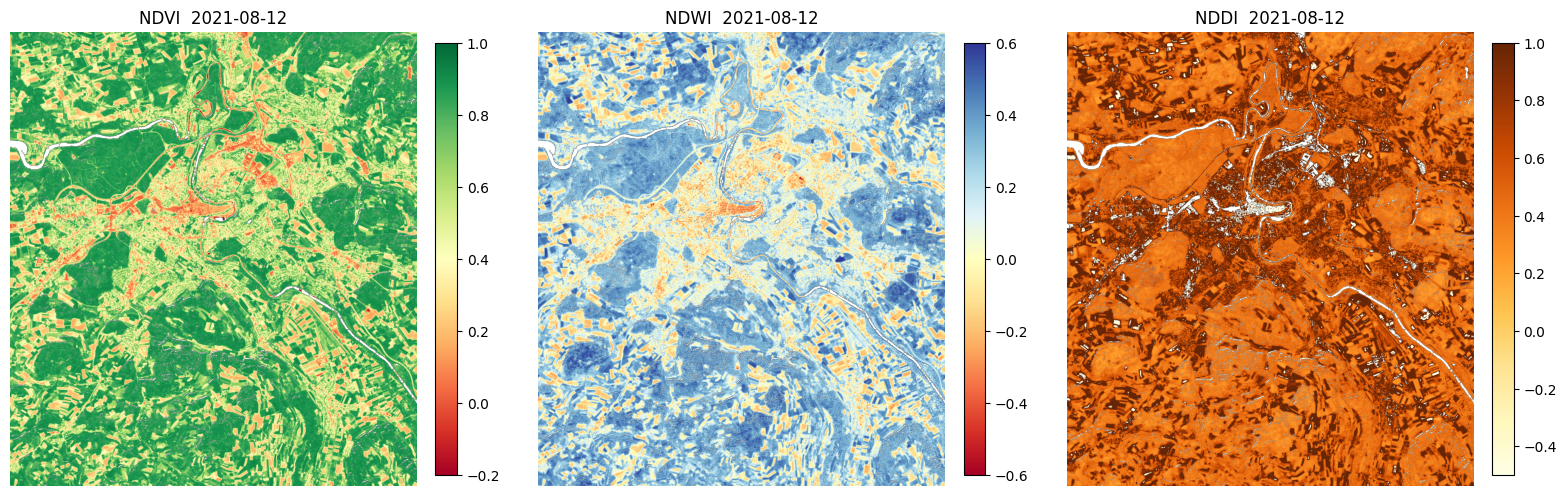

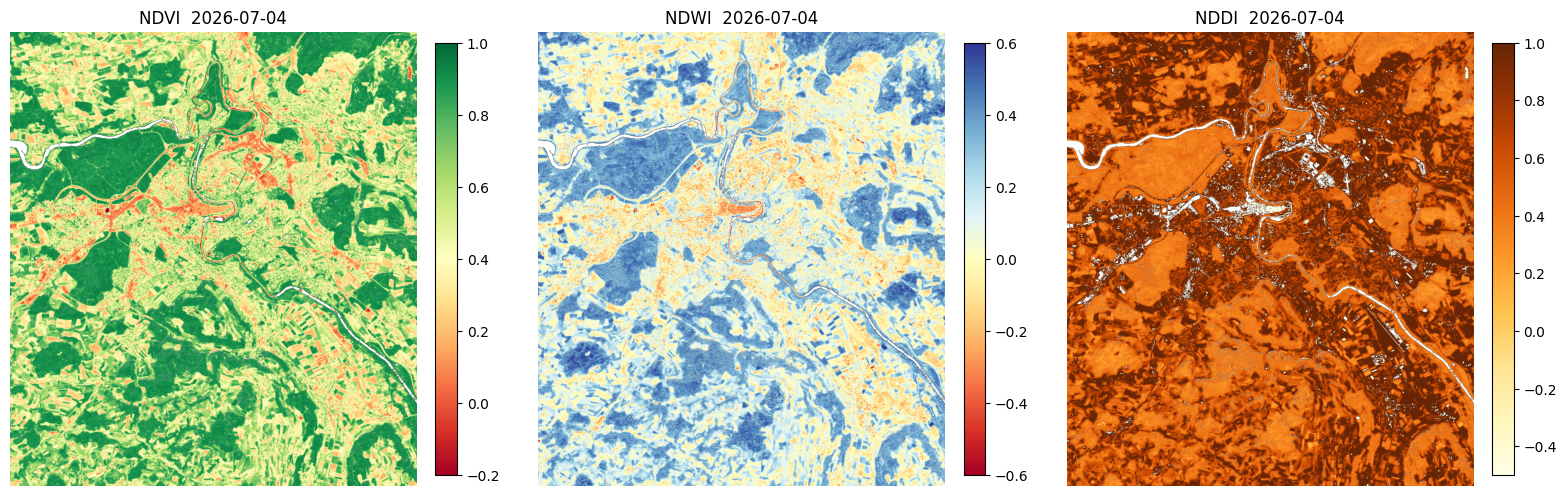

In [9]:
for date_str in DATES:
    r = results[date_str]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    im0 = axes[0].imshow(r["ndvi"], cmap="RdYlGn", vmin=-0.2, vmax=1.0)
    axes[0].set_title(f"NDVI  {date_str}")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(r["ndwi"], cmap="RdYlBu", vmin=-0.6, vmax=0.6)
    axes[1].set_title(f"NDWI  {date_str}")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(r["nddi"], cmap="YlOrBr", vmin=-0.5, vmax=1.0)
    axes[2].set_title(f"NDDI  {date_str}")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## 7&nbsp;&ndash;&nbsp;NDDI change between the two dates
<hr style="border:1px solid #0077b9;">

Positive values (red) = NDDI went up = more drought stress in 2026 than in 2021.
Both dates are single mosaics from different times of the growing season, so
agricultural fields will differ simply because of the crop calendar; forest
pixels are the more consistent comparison.

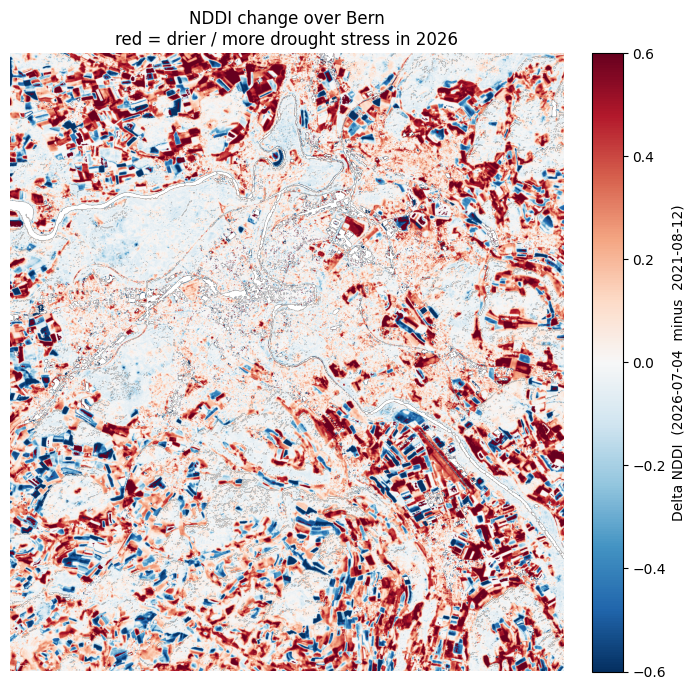

median Delta NDDI = +0.015


In [10]:
nddi_diff = results["2026-07-04"]["nddi"] - results["2021-08-12"]["nddi"]

plt.figure(figsize=(8, 7))
im = plt.imshow(nddi_diff, cmap="RdBu_r", vmin=-0.6, vmax=0.6)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Delta NDDI  (2026-07-04  minus  2021-08-12)")
plt.title("NDDI change over Bern\nred = drier / more drought stress in 2026")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"median Delta NDDI = {np.nanmedian(nddi_diff):+.3f}")

## 8&nbsp;&ndash;&nbsp;Simple drought-stress classes
<hr style="border:1px solid #0077b9;">

A crude fixed-threshold split of the NDDI, only to read the maps more easily.

2021-08-12  none/wet :   1.6%
2021-08-12  mild     :  22.5%
2021-08-12  moderate :  38.1%
2021-08-12  severe   :  37.8%
2026-07-04  none/wet :   1.5%
2026-07-04  mild     :  18.4%
2026-07-04  moderate :  27.4%
2026-07-04  severe   :  52.7%


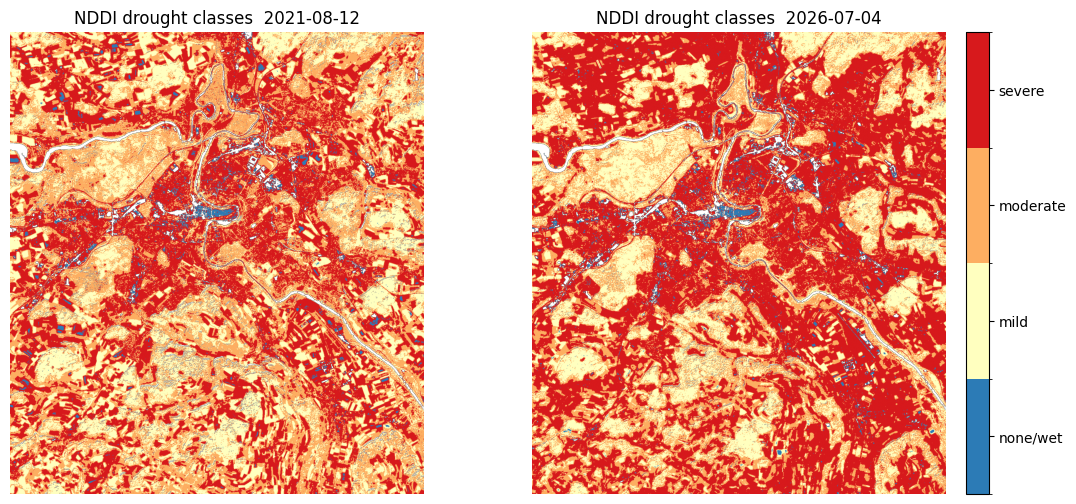

In [11]:
def classify_nddi(nddi):
    classes = np.full(nddi.shape, np.nan, dtype="float32")
    classes[nddi < 0.2] = 0                      # none / wet
    classes[(nddi >= 0.2) & (nddi < 0.4)] = 1    # mild
    classes[(nddi >= 0.4) & (nddi < 0.6)] = 2    # moderate
    classes[nddi >= 0.6] = 3                     # severe
    return classes


from matplotlib.colors import ListedColormap, BoundaryNorm

cmap = ListedColormap(["#2c7bb6", "#ffffbf", "#fdae61", "#d7191c"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)
labels = ["none/wet", "mild", "moderate", "severe"]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, date_str in zip(axes, DATES):
    cls = classify_nddi(results[date_str]["nddi"])
    im = ax.imshow(cls, cmap=cmap, norm=norm)
    ax.set_title(f"NDDI drought classes  {date_str}")
    ax.axis("off")

    valid = np.isfinite(cls)
    for value, label in enumerate(labels):
        frac = np.mean(cls[valid] == value) * 100
        print(f"{date_str}  {label:9s}: {frac:5.1f}%")

cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02, ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(labels)
plt.show()

## References
<hr style="border:1px solid #0077b9;">

- openEO community example: [NDDI_Drought.ipynb](https://github.com/Open-EO/openeo-community-examples/blob/main/python/NDDI/NDDI_Drought.ipynb)
- Gu, Y. et al. (2007). *A five-year analysis of MODIS NDVI and NDWI for grassland drought assessment over the central Great Plains of the United States.* Geophysical Research Letters, 34(6).
- SwissEO S2-SR STAC collection: `ch.swisstopo.swisseo_s2-sr_v200` on [data.geo.admin.ch](https://data.geo.admin.ch/api/stac/v0.9/collections/ch.swisstopo.swisseo_s2-sr_v200)

## See also
<hr style="border:1px solid #0077b9;">

- [Introduction to the SpatioTemporal Asset Catalog (STAC)](../stac/stac-introduction.ipynb)
- [Image processing on images obtained through STAC](../stac/stac-image-processing.ipynb)